# Experimento: Processamento de Áudio em Tempo Real
---
**Objetivo:** Visualizar a relação entre o **domínio do tempo** (onda sonora) e o **domínio da frequência** (espectro) utilizando Python.

Neste experimento, capturamos o áudio do microfone, aplicamos a **Transformada Rápida de Fourier (FFT)** e plotamos os resultados instantaneamente.

## 1. Fundamentos Teóricos

### A. Domínio do Tempo vs. Domínio da Frequência
* **Tempo:** Mostra como a pressão do ar (amplitude) varia ao longo dos segundos. É o que vemos em um osciloscópio.
* **Frequência:** Através da FFT, decompomos essa onda complexa em senoides simples. Isso nos revela quais "notas" ou frequências compõem aquele som.

### B. Teorema da Amostragem (Nyquist)
Para capturar um som de até 20 kHz (limite humano), precisamos de uma taxa de amostragem ($f_s$) de pelo menos o dobro. Aqui usamos **44.1 kHz**, o padrão de qualidade de CD.

**Bibliotecas Necessárias:**
* `sounddevice`: Interface com o hardware de áudio.
* `scipy.fft`: Algoritmos otimizados para a Transformada de Fourier.
* `matplotlib`: Renderização dos gráficos e animação.

In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import sounddevice as sd
from scipy.fft import fft, fftfreq, fftshift

## 1. Configurações de Amostragem
Definimos a taxa de amostragem ($F_s$) baseada no critério de **Nyquist-Shannon**. Para cobrir a faixa audível (até 20 kHz), utilizamos 44.1 kHz.

* **$F_s$ (44100 Hz):** Frequência de amostragem.
* **Duration (0.1s):** Tempo de integração para cada frame da animação.
* **Samples:** Número total de pontos por captura ($F_s \times \text{Duration}$).

In [2]:
FS = 44100         # Taxa de amostragem (44.1 kHz)
DURATION = 0.1     # Janela de tempo a ser mostrada (0.1 segundos)
SAMPLES = int(FS * DURATION)

## 2. A Transformada de Fourier e Conversão para dB
Nesta parte, o código realiza o processamento matemático central:

### FFT Shift
Por padrão, a função `fft` retorna as frequências de $0$ até $F_s$. Aplicamos o `fftshift` para reorganizar os dados e colocar o **DC (0 Hz) no centro**, permitindo a visualização simétrica (estilo rádio).

### Escala em Decibéis (dB)
A amplitude linear do sinal muitas vezes esconde detalhes de baixa potência. Convertemos a magnitude para dB usando a fórmula:
$$Gain_{dB} = 20 \cdot \log_{10}(|X(f)|)$$
Onde $|X(f)|$ é a magnitude da FFT. Somamos uma constante ínfima ($1e^{-10}$) para evitar o erro matemático de calcular o $\log(0)$ durante períodos de silêncio.

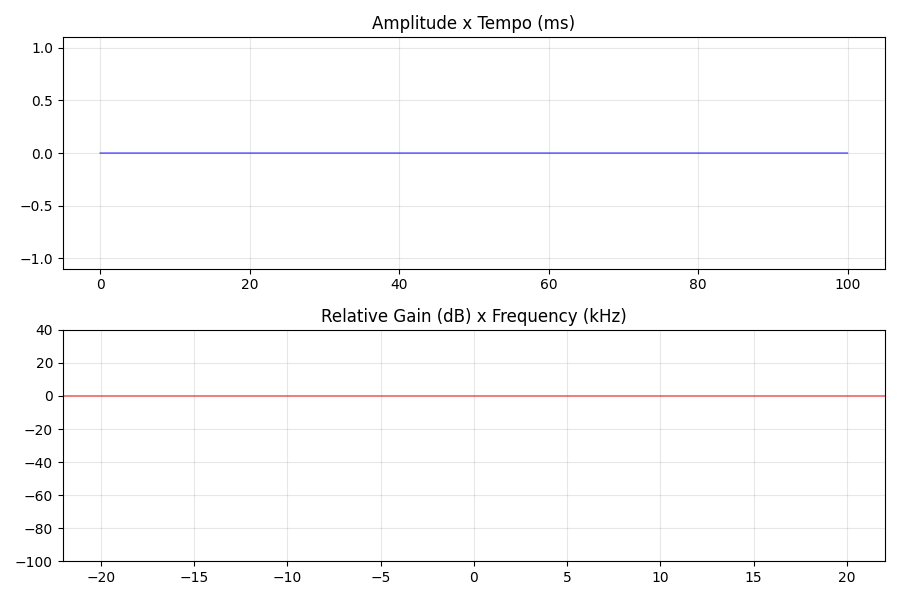

In [ ]:
# --- Configurações ---
FS = 44100         
DURATION = 0.1     
SAMPLES = int(FS * DURATION)

# Criar a figura
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

# 1. Configurar Gráfico do Tempo
x_time = np.linspace(0, DURATION * 1000, SAMPLES) 
line_time, = ax1.plot(x_time, np.zeros(SAMPLES), color='blue', lw=0.7)
ax1.set_ylim(-1.1, 1.1) 
ax1.set_title("Amplitude x Tempo (ms)")
ax1.grid(True, alpha=0.3)

# 2. Configurar Gráfico da Frequência
xf = fftfreq(SAMPLES, 1/FS)
xf_shifted = fftshift(xf) / 1000 
line_freq, = ax2.plot(xf_shifted, np.zeros(SAMPLES), color='red', lw=0.7)
ax2.set_xlim(-FS/(2*1000), FS/(2*1000))
ax2.set_ylim(-60, 70) # Ajustei para -100dB para você ver o ruído de fundo
ax2.set_title("Relative Gain (dB) x Frequency (kHz)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Função de atualização
def update(frame):
    # Captura áudio do microfone
    recording = sd.rec(SAMPLES, samplerate=FS, channels=1, blocking=True)
    sd.wait()
    data = recording.flatten()

    # Atualiza gráfico do tempo
    line_time.set_ydata(data)

    # Cálculo da FFT e conversão para dB
    yf = fft(data)
    yf_shifted = fftshift(yf)
    yf_db = 20 * np.log10(np.abs(yf_shifted) + 1e-10)
    
    line_freq.set_ydata(yf_db)
    return line_time, line_freq

# ATENÇÃO: blit=False no VS Code costuma ser mais estável para animações interativas
ani = FuncAnimation(fig, update, interval=30, blit=True, cache_frame_data=False)

plt.show()

## 3. Análise dos Resultados
Ao rodar o visualizador, observe:
* **Simetria:** Como o sinal capturado é real (não complexo/IQ), o espectro de frequências negativas é uma imagem espelhada das positivas.
* **Noise Floor:** A linha de base no gráfico de frequência (geralmente entre -60 dB e -80 dB) representa o ruído térmico e do ADC do seu computador.
* **Picos de Voz:** Ao falar, você verá os picos de energia subindo instantaneamente na escala de decibéis.